---

# 📘 Probabilidad, valor esperado, variabilidad y distribuciones

**Propósito**: Simular eventos aleatorios simples, explorar distribuciones discretas y continuas, y comprender la Ley de los Grandes Números y el Teorema del Límite Central.

**Autor original**: Pastor E. Pérez Estigarribia  
**Adaptación Python**: Microsoft Copilot  
**Fecha original**: 2022-10-11

---

## 🧾 Rúbrica de Autoevaluación

| **Competencia** | **Indicador de logro** | 🟢 Alto | 🟡 Medio | 🔴 Inicial |
|-----------------|------------------------|--------|----------|------------|
| Comprensión de distribuciones | Identifica y describe distribuciones discretas y continuas | ✔️ | ⚠️ | ❌ |
| Implementación en Python | Ejecuta simulaciones y visualizaciones sin errores | ✔️ | ⚠️ | ❌ |
| Interpretación gráfica | Analiza histogramas, densidades y Q-Q plots | ✔️ | ⚠️ | ❌ |
| Aplicación de conceptos | Relaciona simulaciones con LGN y TLC | ✔️ | ⚠️ | ❌ |
| Documentación y reflexión | Comenta el código y reflexiona sobre resultados | ✔️ | ⚠️ | ❌ |

---


## ⚙️ Preámbulo



In [ ]:
# Instalar paquetes necesarios
!pip install numpy pandas matplotlib seaborn scipy

# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binom, norm, expon

## 🔢 1. Lanzamiento de monedas o dados

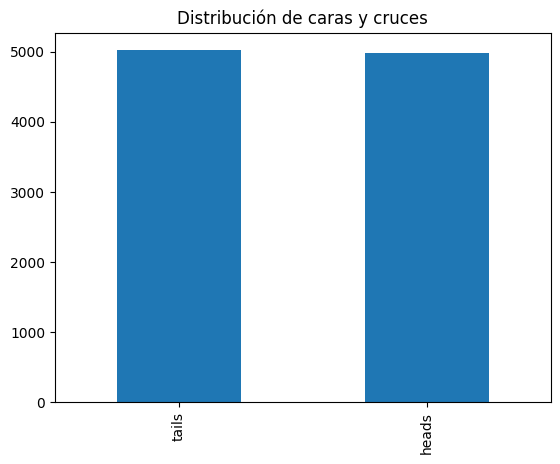

In [ ]:
# sample() para generar muestras aleatorias
np.random.choice(["heads", "tails"], size=100, replace=True)

# Muestra pequeña y gráfico de barras
data = np.random.choice(["heads", "tails"], size=10000, replace=True)
pd.Series(data).value_counts().plot(kind="bar", title="Distribución de caras y cruces")
plt.show()


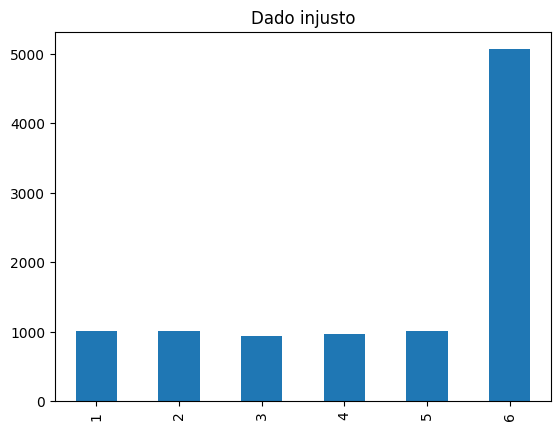

In [ ]:
# Lanzamiento de dados
np.random.choice(range(1, 7), size=6, replace=True)
np.random.choice(range(1, 7), size=10, replace=True)

# Dado injusto
data = np.random.choice(range(1, 7), size=10000, replace=True,
                        p=[0.1, 0.1, 0.1, 0.1, 0.1, 0.5])
pd.Series(data).value_counts().sort_index().plot(kind="bar", title="Dado injusto")
plt.show()

## 🎯 2. Distribuciones discretas

[Bernoulli: X ∼ Bernoulli(p)](https://es.wikipedia.org/wiki/Distribuci%C3%B3n_Bernoulli)

In [ ]:
# Bernoulli: X ∼ Bernoulli(p) con valores {0,1}
np.random.binomial(n=1, p=0.7, size=1)

array([1])

In [ ]:
np.random.binomial(n=1, p=0.7, size=20)

array([1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0])

In [ ]:
np.random.binomial(n=3, p=0.7, size=20)

array([1, 2, 2, 2, 3, 2, 3, 1, 3, 2, 2, 2, 3, 1, 3, 2, 2, 1, 2, 3])

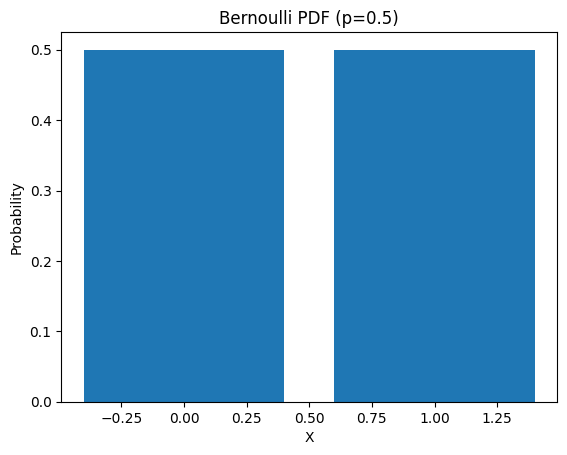

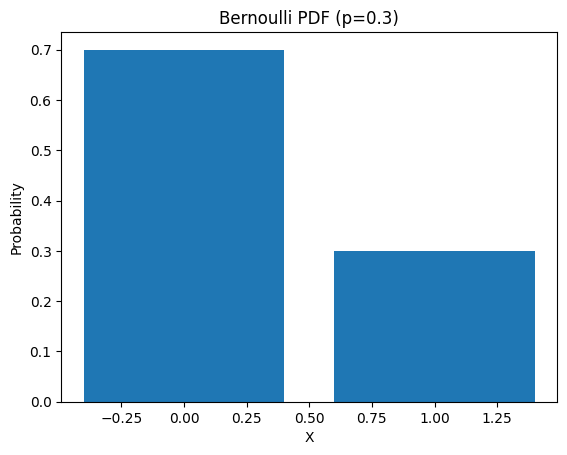

In [ ]:
# Función de densidad binomial
x = [0, 1]
y1 = binom.pmf(x, n=1, p=0.5)
y2 = binom.pmf(x, n=1, p=0.3)

plt.bar(x, y1)
plt.title("Bernoulli PDF (p=0.5)")
plt.xlabel("X")
plt.ylabel("Probability")
plt.show()

plt.bar(x, y2)
plt.title("Bernoulli PDF (p=0.3)")
plt.xlabel("X")
plt.ylabel("Probability")
plt.show()

## 📈 3. Distribuciones continuas

In [ ]:
# Normal estándar y general
np.random.normal(loc=5, scale=2, size=1000).std()




np.float64(2.027771036722213)

In [ ]:
np.random.normal(size=5)

array([ 0.87450033, -1.80949701, -1.60239365,  0.96375239,  0.873442  ])

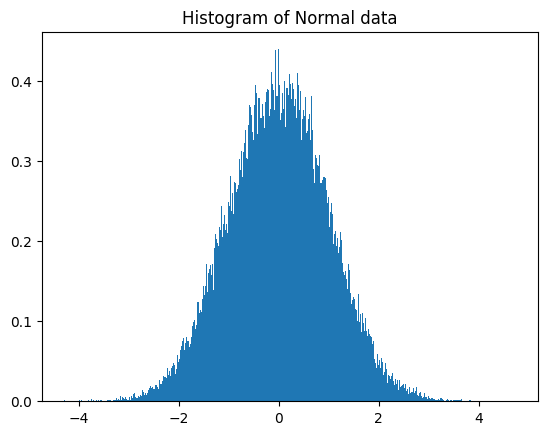

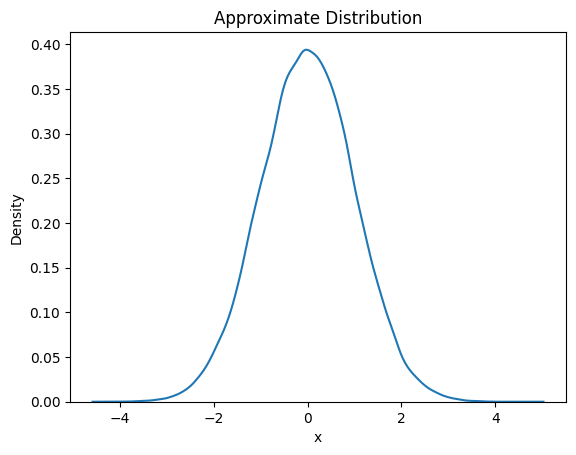

In [ ]:
# Histograma y densidad
samp = np.random.normal(size=100000)
plt.hist(samp, bins=1000, density=True)
plt.title("Histogram of Normal data")
plt.show()


sns.kdeplot(samp)
plt.title("Approximate Distribution")
plt.xlabel("x")
plt.ylabel("Density")
plt.show()

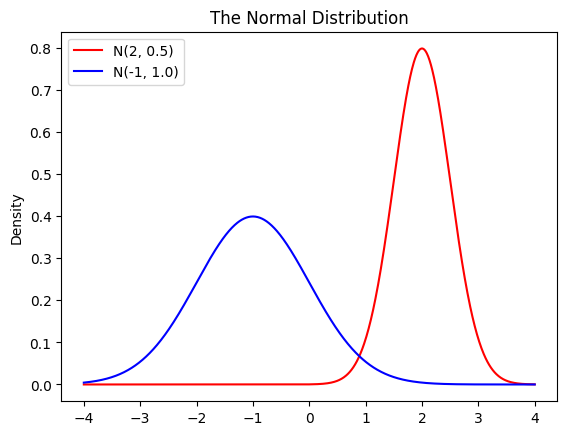

In [ ]:
# Comparación de distribuciones normales
x_vals = np.linspace(-4, 4, 1000)
plt.plot(x_vals, norm.pdf(x_vals, loc=2, scale=0.5), color="red", label="N(2, 0.5)")
plt.plot(x_vals, norm.pdf(x_vals, loc=-1, scale=1), color="blue", label="N(-1, 1.0)")
plt.title("The Normal Distribution")
plt.ylabel("Density")
plt.legend()
plt.show()

In [ ]:
np.linspace(0.01, 0.99, 99)

array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 , 0.11,
       0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21, 0.22,
       0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32, 0.33,
       0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43, 0.44,
       0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54, 0.55,
       0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65, 0.66,
       0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77,
       0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88,
       0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99])

## 📊 4. Normalidad y cuantiles

[-2.32224117e+00 -2.05071920e+00 -1.87839006e+00 -1.74970356e+00
 -1.64449836e+00 -1.55580393e+00 -1.47639146e+00 -1.40578595e+00
 -1.34272216e+00 -1.28354824e+00 -1.22807382e+00 -1.17682245e+00
 -1.12814853e+00 -1.08301858e+00 -1.03913305e+00 -9.96952671e-01
 -9.56764187e-01 -9.16946622e-01 -8.79149295e-01 -8.42966099e-01
 -8.07769634e-01 -7.73049346e-01 -7.39681493e-01 -7.07282649e-01
 -6.75882217e-01 -6.45239312e-01 -6.14386772e-01 -5.84931500e-01
 -5.55337955e-01 -5.26610727e-01 -4.98056677e-01 -4.69763902e-01
 -4.41760169e-01 -4.13849373e-01 -3.86647022e-01 -3.60115241e-01
 -3.32983254e-01 -3.06709660e-01 -2.80780505e-01 -2.54407003e-01
 -2.28352119e-01 -2.02605633e-01 -1.77452908e-01 -1.51939333e-01
 -1.26776515e-01 -1.01336093e-01 -7.63932125e-02 -5.09406163e-02
 -2.58701715e-02 -8.96502842e-04  2.40956328e-02  4.97087386e-02
  7.48742235e-02  1.00255159e-01  1.25347354e-01  1.50618556e-01
  1.76039556e-01  2.01280928e-01  2.26736720e-01  2.52511293e-01
  2.79008052e-01  3.05101

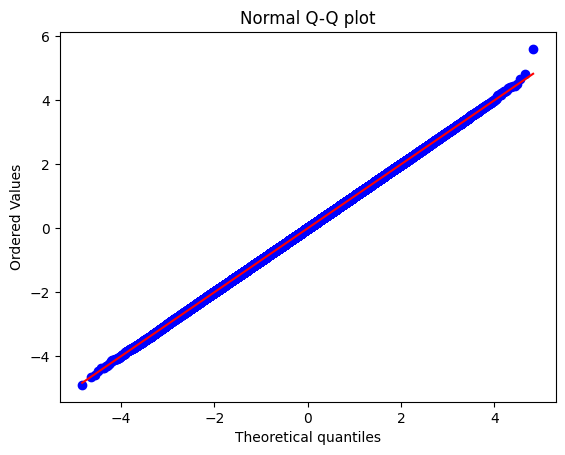

In [ ]:
# Cuantiles

samp = np.random.normal(size=1000000)
quantiles = np.quantile(samp, q=np.linspace(0.01, 0.99, 99))
print(quantiles)

# Q-Q plot
from scipy import stats
stats.probplot(samp, dist="norm", plot=plt)
plt.title("Normal Q-Q plot")
plt.show()

## 📉 5. Distribución exponencial

In [ ]:
1/0.2

5.0

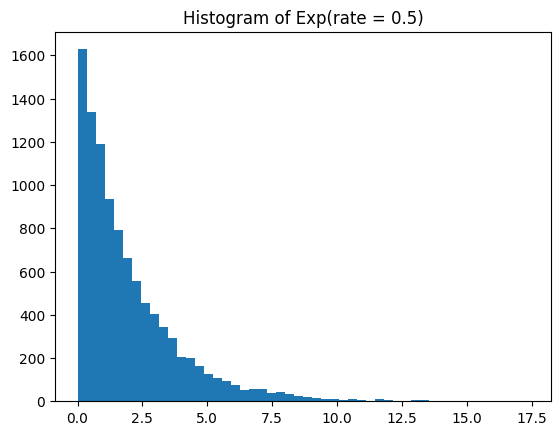

In [ ]:
# Muestras exponenciales
np.random.exponential(scale=1/0.2, size=5)

# Histograma de 10,000 muestras
data = np.random.exponential(scale=1/0.5, size=10000)
plt.hist(data, bins=50)
plt.title("Histogram of Exp(rate = 0.5)")
plt.show()

## 👶 6. Frecuencia a largo plazo: Niñas y niños

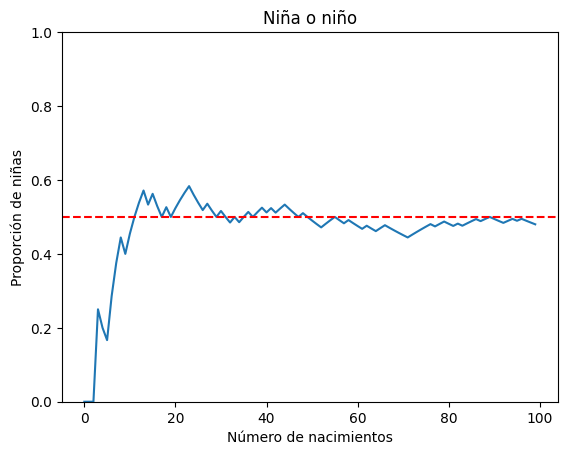

In [ ]:
# Simulación de nacimientos
flips = np.random.choice(["XX", "XY"], size=100, replace=True)
proporciones = np.cumsum(flips == "XX") / np.arange(1, len(flips)+1)

plt.plot(proporciones)
plt.axhline(y=0.5, color="red", linestyle="--")
plt.title("Niña o niño")
plt.xlabel("Número de nacimientos")
plt.ylabel("Proporción de niñas")
plt.ylim(0, 1)
plt.show()

---

## 🧪 7. Problemas de desafío

### 🔹 Desafío 1: Simula una distribución binomial con parámetros personalizados y grafica su densidad.

### 🔹 Desafío 2: Genera una muestra normal con media 10 y desviación estándar 2. Introduce tres valores atípicos y analiza su impacto en el histograma, boxplot y Q-Q plot.

### 🔹 Desafío 3: Simula 1 millón de nacimientos y verifica si la proporción de niñas converge a 0.5.

---



---

## 🧪 Actividad práctica extendida: Distribuciones, probabilidad acumulada y Teorema del Límite Central

### 📘 Propósito

Simular eventos aleatorios simples, explorar distribuciones discretas y continuas, aplicar la Ley de los Grandes Números y el Teorema del Límite Central, y comparar distribuciones empíricas con teóricas.

### Contenido

- Función de distribución acumulada (FDA)
- Comparación entre distribución empírica y teórica
- Visualización de áreas bajo la curva
- Diagrama Q-Q y prueba de Shapiro-Wilk
- Simulación del Teorema del Límite Central

---


### ⚙️ Preámbulo

In [ ]:
!pip install numpy pandas matplotlib seaborn scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, shapiro

## 📏 Función de distribución acumulada (FDA)

In [ ]:
# Simulamos estaturas de hombres en metros
np.random.seed(42)
hombres = np.random.normal(loc=1.75, scale=0.1, size=1000)

# FDA: proporción de hombres que miden ≤ x
def FDA(x):
    return np.mean(hombres <= x)

# Probabilidad de medir ≤ 2.4m
prob = FDA(1.65)
print("P(x ≤ 1.65):", prob)

P(x ≤ 1.65): 0.147


In [ ]:
hombres = np.random.normal(loc=1.75, scale=0.1, size=1000)
hombres

array([1.55921924, 1.6639615 , 1.70863945, 1.93876877, 1.80565531,
       1.61645184, 1.79860363, 1.5952696 , 1.85826911, 1.70288753,
       1.74063638, 1.88257966, 1.62128364, 1.61028818, 1.69164007,
       1.85383789, 1.59806539, 1.46678444, 1.70488411, 1.80517408,
       1.87002617, 1.70368386, 1.70885734, 1.86539007, 1.56302583,
       1.71114792, 1.76904239, 1.79492187, 1.69901933, 1.7534441 ,
       1.50116726, 1.68417516, 1.79535087, 1.6517706 , 1.75589842,
       1.79468725, 1.71574508, 1.76704638, 1.65372674, 1.72933887,
       1.81102162, 1.7656973 , 1.69134687, 1.77242164, 1.82146098,
       1.54500587, 1.86590741, 1.71637453, 1.79254899, 1.86972469,
       1.61283263, 1.6790559 , 1.72114513, 1.67162465, 1.92349366,
       1.66432279, 1.69444532, 1.7704389 , 1.62978505, 1.71043193,
       1.78174533, 1.71671396, 1.74066131, 1.69706679, 1.59855297,
       1.78215932, 1.92549331, 1.75184016, 1.77252641, 1.81927228,
       1.62306695, 1.92025147, 1.77023288, 1.91318569, 1.67669

In [ ]:

# Probabilidad de medir > 1.80m
print("P(x > 1.80):", 1 - FDA(1.80))

P(x > 1.80): 0.30600000000000005


In [ ]:
# Probabilidad de medir entre 1.6m y 1.95m
print("P(1.6 < x ≤ 1.95):", FDA(1.95) - FDA(1.6))

P(1.6 < x ≤ 1.95): 0.9189999999999999


## 📊 Comparación empírica vs teórica

In [ ]:
# Parámetros empíricos
promedio = np.mean(hombres)
desv_est = np.std(hombres)

# Probabilidad teórica con pnorm
prob_teorica = norm.cdf(1.65, loc=promedio, scale=desv_est)
print("P(x ≤ 1.65) teórica:", prob_teorica)

P(x ≤ 1.65) teórica: 0.16957716825701363


In [ ]:
sec = np.linspace(promedio - 4*desv_est, promedio + 4*desv_est, 100)

sec

array([1.33748055, 1.34577646, 1.35407237, 1.36236828, 1.37066418,
       1.37896009, 1.387256  , 1.39555191, 1.40384782, 1.41214373,
       1.42043964, 1.42873555, 1.43703146, 1.44532737, 1.45362328,
       1.46191919, 1.4702151 , 1.47851101, 1.48680692, 1.49510283,
       1.50339874, 1.51169465, 1.51999056, 1.52828647, 1.53658238,
       1.54487829, 1.5531742 , 1.56147011, 1.56976602, 1.57806193,
       1.58635784, 1.59465375, 1.60294966, 1.61124557, 1.61954148,
       1.62783739, 1.6361333 , 1.64442921, 1.65272512, 1.66102103,
       1.66931694, 1.67761285, 1.68590876, 1.69420466, 1.70250057,
       1.71079648, 1.71909239, 1.7273883 , 1.73568421, 1.74398012,
       1.75227603, 1.76057194, 1.76886785, 1.77716376, 1.78545967,
       1.79375558, 1.80205149, 1.8103474 , 1.81864331, 1.82693922,
       1.83523513, 1.84353104, 1.85182695, 1.86012286, 1.86841877,
       1.87671468, 1.88501059, 1.8933065 , 1.90160241, 1.90989832,
       1.91819423, 1.92649014, 1.93478605, 1.94308196, 1.95137

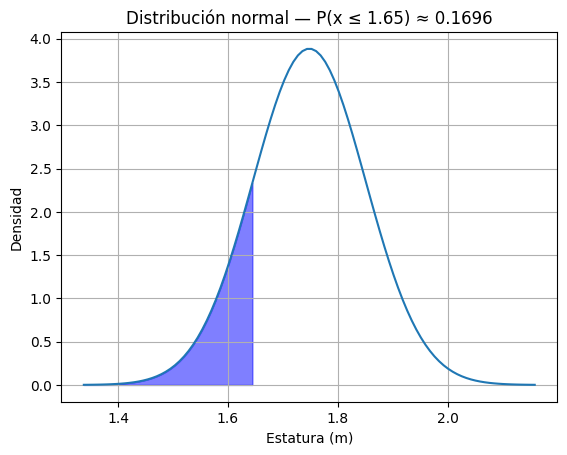

In [ ]:
# Área bajo la curva: P(x ≤ 1.65)
sec = np.linspace(promedio - 4*desv_est, promedio + 4*desv_est, 100)
densidad = norm.pdf(sec, loc=promedio, scale=desv_est)

plt.plot(sec, densidad)
plt.fill_between(sec, 0, densidad, where=(sec <= 1.65), color='blue', alpha=0.5)
plt.title(f"Distribución normal — P(x ≤ 1.65) ≈ {round(prob_teorica, 4)}")
plt.xlabel("Estatura (m)")
plt.ylabel("Densidad")
plt.grid(True)
plt.show()

## 📈 Área entre dos valores

P(1.6 < x ≤ 1.95) teórica: 0.9008443371639168


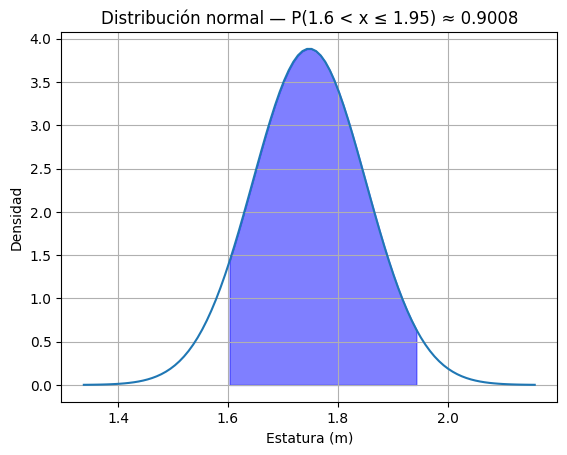

In [ ]:
# P(1.6 < x ≤ 1.95) teórica
prob_teo_intervalo = norm.cdf(1.95, promedio, desv_est) - norm.cdf(1.6, promedio, desv_est)
print("P(1.6 < x ≤ 1.95) teórica:", prob_teo_intervalo)

plt.plot(sec, densidad)
plt.fill_between(sec, 0, densidad, where=(sec > 1.6) & (sec <= 1.95), color='blue', alpha=0.5)
plt.title(f"Distribución normal — P(1.6 < x ≤ 1.95) ≈ {round(prob_teo_intervalo, 4)}")
plt.xlabel("Estatura (m)")
plt.ylabel("Densidad")
plt.grid(True)
plt.show()

## 📐 Diagrama Q-Q y prueba de normalidad

In [ ]:
estatura_z = (hombres - promedio) / desv_est
estatura_z

array([-1.84010685, -0.81984254, -0.38464745,  1.85697634,  0.56035631,
       -1.28262049,  0.49166788, -1.48895065,  1.0728522 , -0.44067518,
       -0.07297448,  1.3096544 , -1.23555531, -1.34265896, -0.55023354,
        1.02968895, -1.46171764, -2.7404878 , -0.42122707,  0.55566876,
        1.18737445, -0.43291836, -0.38252502,  1.14221551, -1.80302799,
       -0.36021311,  0.20372031,  0.45580494, -0.47835424,  0.05178186,
       -2.40557455, -0.62294707,  0.4599837 , -0.93859063,  0.07568869,
        0.45351956, -0.31543351,  0.18427773, -0.91953636, -0.18302028,
        0.61262795,  0.17113672, -0.55308946,  0.23663663,  0.71431478,
       -1.97855523,  1.1472547 , -0.30930226,  0.43269141,  1.18443779,
       -1.31787421, -0.67281231, -0.26283317, -0.745198  ,  1.70818588,
       -0.8163233 , -0.52290835,  0.21732336, -1.15274557, -0.36718739,
        0.32745598, -0.30599593, -0.07273161, -0.4973734 , -1.4569683 ,
        0.33148859,  1.7276639 ,  0.03615836,  0.23765718,  0.69

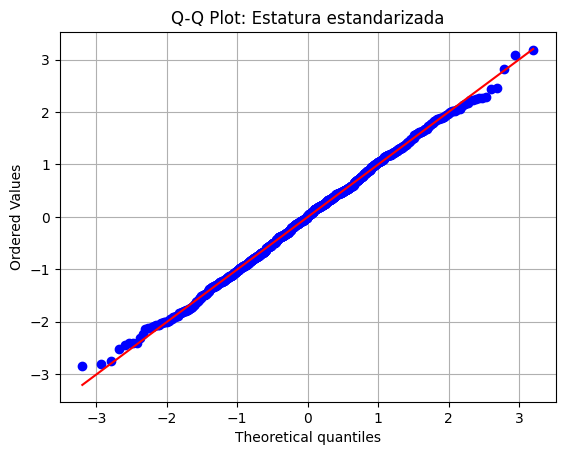

In [ ]:
# Estandarización
estatura_z = (hombres - promedio) / desv_est

# Q-Q plot
from scipy import stats
stats.probplot(estatura_z, dist="norm", plot=plt)
plt.title("Q-Q Plot: Estatura estandarizada")
plt.grid(True)
plt.show()

Prueba de [Shapiro-Wilk](https://en.wikipedia.org/wiki/Shapiro%E2%80%93Wilk_test)

In [ ]:

stat, p_value = shapiro(estatura_z)
print("Shapiro-Wilk p-value:", p_value)

Shapiro-Wilk p-value: 0.48378570102434804


## 📚 Teorema del Límite Central (CLT)

In [ ]:
# Muestras de tamaño 10, 20, 50
#np.random.seed(1727498)
e10 = np.random.exponential(scale=1/0.2, size=10)
e20 = np.random.exponential(scale=1/0.2, size=20)
e50 = np.random.exponential(scale=1/0.2, size=50)

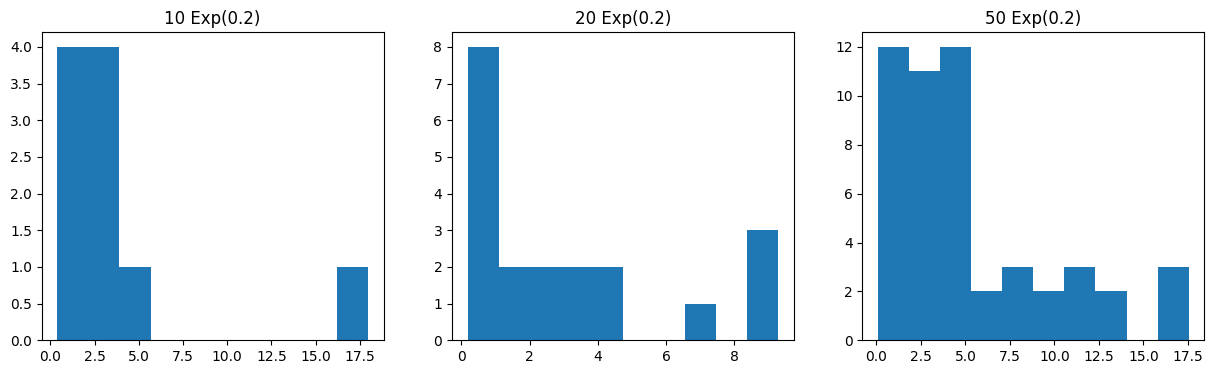

In [ ]:
# Histogramas
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].hist(e10, bins=10)
axs[0].set_title("10 Exp(0.2)")
axs[1].hist(e20, bins=10)
axs[1].set_title("20 Exp(0.2)")
axs[2].hist(e50, bins=10)
axs[2].set_title("50 Exp(0.2)")
plt.show()

## 📊 Distribución muestral de la media

In [ ]:
e10bar

[np.float64(4.412238438124825),
 np.float64(4.409521040218525),
 np.float64(5.03819316384983),
 np.float64(6.70386411676264),
 np.float64(6.296495224678836),
 np.float64(7.072729750122635),
 np.float64(3.253516328835834),
 np.float64(3.4682001690142505),
 np.float64(4.8075189950303665),
 np.float64(6.99071922665915),
 np.float64(4.707056225499953),
 np.float64(4.402492342281837),
 np.float64(5.83993175988123),
 np.float64(5.174267766300458),
 np.float64(2.692585410113509),
 np.float64(5.969824704467337),
 np.float64(6.200042506048108),
 np.float64(5.193287956622195),
 np.float64(7.518362793645022),
 np.float64(6.539400119686169),
 np.float64(5.081620281400919),
 np.float64(5.658127799303125),
 np.float64(4.248204084150847),
 np.float64(4.950976735238589),
 np.float64(5.771337757353338),
 np.float64(6.374007553134488),
 np.float64(2.193358501868425),
 np.float64(6.731595558163981),
 np.float64(4.138760814724134),
 np.float64(3.218531129532974),
 np.float64(5.957217164371048),
 np.float6

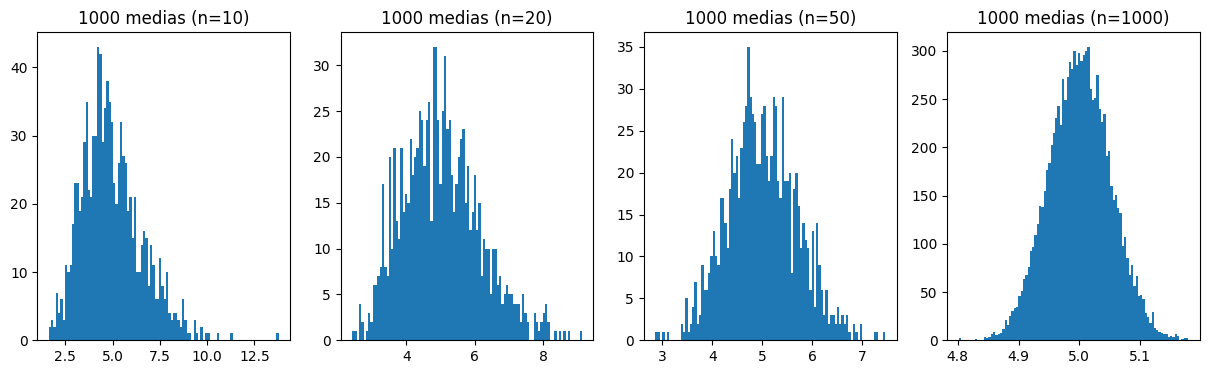

In [ ]:
# Simulación de medias
#np.random.seed(81793)
e10bar = [np.mean(np.random.exponential(scale=1/0.2, size=10)) for _ in range(1000)]
e20bar = [np.mean(np.random.exponential(scale=1/0.2, size=20)) for _ in range(1000)]
e50bar = [np.mean(np.random.exponential(scale=1/0.2, size=50)) for _ in range(1000)]
e1000bar = [np.mean(np.random.exponential(scale=1/0.2, size=10000)) for _ in range(10000)]

# Histogramas
fig, axs = plt.subplots(1, 4, figsize=(15, 4))
axs[0].hist(e10bar, bins=100)
axs[0].set_title("1000 medias (n=10)")
axs[1].hist(e20bar, bins=100)
axs[1].set_title("1000 medias (n=20)")
axs[2].hist(e50bar, bins=100)
axs[2].set_title("1000 medias (n=50)")
axs[3].hist(e1000bar, bins=100)
axs[3].set_title("1000 medias (n=1000)")
plt.show()

## 📈 Q-Q plots de medias

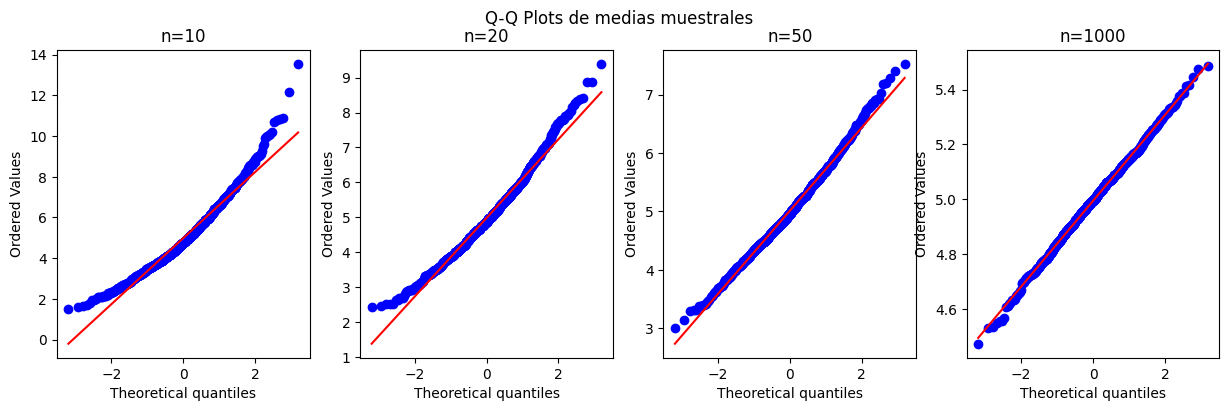

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=(15, 4))
stats.probplot(e10bar, dist="norm", plot=axs[0])
axs[0].set_title("n=10")
stats.probplot(e20bar, dist="norm", plot=axs[1])
axs[1].set_title("n=20")
stats.probplot(e50bar, dist="norm", plot=axs[2])
axs[2].set_title("n=50")
stats.probplot(e1000bar, dist="norm", plot=axs[3])
axs[3].set_title("n=1000")
plt.suptitle("Q-Q Plots de medias muestrales")
plt.show()


## 🧾 Rúbrica de Autoevaluación

| **Competencia** | **Indicador de logro** | 🟢 Alto | 🟡 Medio | 🔴 Inicial |
|-----------------|------------------------|--------|----------|------------|
| Comprensión de FDA | Implementa y aplica correctamente la función acumulada | ✔️ | ⚠️ | ❌ |
| Comparación empírica/teórica | Interpreta diferencias entre datos reales y modelos | ✔️ | ⚠️ | ❌ |
| Visualización de áreas | Genera gráficos claros y bien etiquetados | ✔️ | ⚠️ | ❌ |
| Aplicación del CLT | Simula y analiza la distribución muestral | ✔️ | ⚠️ | ❌ |
| Pruebas de normalidad | Ejecuta Q-Q plots y Shapiro-Wilk con interpretación | ✔️ | ⚠️ | ❌ |

---



## 🧩 Problemas finales de desafío

1. **Diseña una función que calcule la probabilidad acumulada para cualquier intervalo de estatura usando datos empíricos.**
2. **Simula 1000 medias muestrales de tamaño 30 y compara su distribución con una normal teórica. ¿Qué observas?**
3. **Modifica la tasa de la distribución exponencial a 0.5 y repite los experimentos del CLT. ¿Cómo cambia la forma de las distribuciones?**